# CIBUSmod example
This notebook privides a step-by-step example of how the model is run and how outputs can be visualised. The model is currently a work in progress, so this notebook will be continuosly updated as the work progresses.

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import pandas as pd
import matplotlib.pyplot as plt

## Run scenario 'Food as industry'

### Set up scenario and modules

Instantiate a `Session` with a `name` and `data_path` to the folder with input data. Next add scenarios to run with `.add_scenario()`. Here we use a scenario defined in `data/scenarios/food_as_industry.xlsx` and calculate outputs for 5-year time-steps from 2020 to 2050.

In [16]:
# Set the Scenario to run: 'food_as_industry', 'food_as_culture', 'no_cows'
selection = 'food_as_culture'

# Create session
session = cm.Session(
    name = selection,
    data_path = '../data'
)


# Creat a session and Define scenario
if selection == 'food_as_industry':
    session.add_scenario(
        name = 'FAI',                           # Name of scenario in outputs
        scenario = 'food_as_industry',          # Name of scenario Excel file
        modules = 'all',                        # Modules to update
        pars = 'all',                           # Parameters to update
        years = ['2020', '2035', '2050']        # Years to calculate
    )
elif selection == 'food_as_culture':
    session.add_scenario(
        name = 'FAC',                           # Name of scenario in outputs
        scenario = 'food_as_industry',          # Name of scenario Excel file
        modules = 'all',                        # Modules to update
        pars = 'all',                           # Parameters to update
        years = ['2020', '2035', '2050']        # Years to calculate
    )
elif selection == 'no_cows':
    session.add_scenario(
        name = 'FAI_no_cows',
        scenario = 'no_cows', 
        modules = 'all',
        pars = 'all',
        years = ['2020', '2035', '2050']
    )
else:
    print("Please set the 'selection' variable at the top of the cell to either 'food_as_industry', 'food_as_culture', 'no_cows'")

A scenario with the name 'FAC' already exists use .update_scenario() or .remove_scenario() instead.


In [15]:
session.remove_scenario('no_cows')

Next, we initialise all model modules (python classes) that handle the calculations.

Each module is intialised with a `ParameterRetriever` object which reads a named parameter Excel-file from the default data folder and handles the retrieval of parameter values used in the calculations. The `ParameterRetriever` also handles updating parameter values according to a scenario.

There are four main modules that store data as attributes (generaly in the form of pandas.DataFrames). These are:

`Regions`
This module handles baselina crop areas and animal numbers ('x0') as well as various regional attrubutes such as climate and soil properties.

`DemandAndConversions`
This module calculates demand for crop and animal production based on population, consumption of different foods, waste and conversion factors, etc. It also calculates waste and by-products generated.

`CropProduction`
This module calculates production of crop products per unit (area) of a certain crop in a certain region.

`AnimalHerd`
This module has subclasses for each animal species (and breed) and is initialised as one AnimalHerd object per combination of species (e.g. cattle), breed (e.g. dairy), production system (e.g. conventional) and sub system (used to represent different feeding strategies, e.g. maize based). The `AnimalHerd` modules calculates production of animal products per animal unit (i.e. a defining animal in the species/breed). The defining animal differs accros species/breeds with e.g. 'cows' for `CattleHerd`s, 'sows+gilts' for `PigHerd`s and 'total horses' for `HorseHerd`s.

There are also a number of management (mgmt) modules that calculates specific aspects on the main modules. These have no data attributes but do have their own parameter Excel-files connected to them. These are:

`FeedMgmt`
Handles the calculation of feed requirements, losses and import shares and the translation from 'feed products' to 'crop products' and 'by-products'.

`ManureMgmt`
Handles the calculation of manure excretion and losses in stables and storage.

`PlantNutrientMgmt`
Handles the calculation of crop fertiliser requirements (N, P and K) and application of manure and mineral fertiliser.

`MachineryAndEnergyMgmt`
Handles the calculation of energy requirements in machinery, drying, greenhouses, stables etc.

`InputsMgmt`
Handles the calculation of supply chain emissions for inputs (currently energy and fertilisers) by retrieving lifecycle inventory data from ecoinvent.

Finaly the module `GeoDistributor` handles the distribution of crop and animal production across regions by solving a convex optimisation problem that minimises the deviation of crop areas and animal numbers for the current situation while meeting demand for crop and animal products as wel as a number of additional constraints.

In [17]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [18]:
session

+------------------+
| CIBUSmod SESSION |
+------------------+
Name: food_as_culture
Active: Yes

SCENARIOS
FAC: 2020, 2035, 2050

OUTPUT DATA

### Run calculations
Now we have initialised all modules and can do the calculations. This is done by looping through scenarios and years via `Session.iterate()` and first updating all parameter values according to the specified scenario and year via `ParameterRetriever.update_all_parameter_values()` and then (re-)calculating all modules. After all main modules have been (re-)calculated we run `GeoDistributor.make()` and `GeoDistributor.solve()` to make and solve the optimisation problem that distribute crops and animals across regions. Then some mgmt modules are calculated and finally ouputs are stored via `Session.store()` before the next iteration.

In [19]:
# Set to true to print progress messages
msg = True

# Loop through scenarios and years
for scn, year in session.iterate('all'):#
    print(scn,year)
    
    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year = year
    )
    
    # Get region attributes
    regions.calculate(verbose=msg)
    
    # Calculate food demand
    demand.calculate(verbose=msg)
    
    # Calculate crops
    crops.calculate(
        verbose=msg
    )
    
    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)
    
    # Calculate feed
    feed_mgmt.calculate(verbose=msg)    
    
    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=msg)
    # Solve optimisation problem (move to next scn/year if it fails)
    try:
        geodist.solve(verbose=msg)
    except Exception as e:
        print(f'(!!!) GeoDistributor failed for {scn}, {year} with the exception: {e}')
        continue
    
    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)
    
    # Calculate manure
    manure_mgmt.calculate(verbose=msg)
    
    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)
    
    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)
    
    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)
    
    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)
    
    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds
    )

FAC 2020
[13:25:02][Regions] Getting initial crop areas and animal numbers (x0) ... 0.1s
[13:25:03][Regions] Getting climate and soil attributes ... 0.1s
[13:25:03][Regions] Calculating maximum land use ... 0.1s
[13:25:03][Regions] Done! Elapsed time: 0 sec
[13:25:03][DemandAndConversions] Calculating food demand ... 0.1s
[13:25:03][DemandAndConversions] Calculating waste ... 

C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\main_modules\demand_and_conversions.py:142: PerformanceWarning: indexing past lexsort depth may impact performance.
  share_per_prod_system.update(share_con)
C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\main_modules\demand_and_conversions.py:142: PerformanceWarning: indexing past lexsort depth may impact performance.
  share_per_prod_system.update(share_con)
C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\main_modules\demand_and_conversions.py:146: PerformanceWarning: indexing past lexsort depth may impact performance.
  share_per_origin.loc[:,'domestic'] = 1 - share_per_origin.loc[:,'imported']


0.0s
[13:25:03][DemandAndConversions] Calculating crop product demand ... 

C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\main_modules\demand_and_conversions.py:304: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  crop_prod_demand = crop_prod_demand.stack('crop_prod').groupby(['prod_system','crop_prod']).sum()
C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\main_modules\demand_and_conversions.py:305: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  crop_by_products = crop_by_products.stack(['crop_prod','by_prod']).groupby(['prod_system','crop_prod','by_prod']).sum()


0.4s
[13:25:03][DemandAndConversions] Calculating animal product demand ... 

...

1.7s
[13:36:17][GeoDistributor.make] Done! Elapsed time: 19 sec
[13:36:17][GeoDistributor.solve] Defining problem ... 0.0s
[13:36:17][GeoDistributor.solve] Finding solution with 'GUROBI' ... Failed with SolverError: The solver GUROBI is not installed. 0.0s
[13:36:17][GeoDistributor.solve] Finding solution with 'OSQP' ... Optimal solution found! Status: 'optimal', Itterations: 116375, Solver: 'OSQP' 0.0s
[13:39:56][GeoDistributor.solve] Retrieving solution ... 0.0s
[13:39:56][GeoDistributor.solve] Applying solution ... 

C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:1596: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(['prod_system','crop_prod'])
C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\optimisation\geo_dist.py:1657: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the origina

4.4s
[13:40:00][GeoDistributor.solve] Done! Elapsed time: 223 sec
[13:40:00][FeedMgmt] Adjusting feed rations (not implemented) ... 0.0s
[13:40:00][FeedMgmt] Calculating feed ration characteristics ... 10.4s
[13:40:11][FeedMgmt] Calculating enteric methane emissions ... 1.7s
[13:40:12][FeedMgmt] Done! Elapsed time: 12 sec
[13:40:12][ManureMgmt] Calculating MMS shares ... 5.7s
[13:40:18][ManureMgmt] Calculating bedding material use ... 4.2s
[13:40:22][ManureMgmt] Calculating VS excretion ... 0.8s
[13:40:23][ManureMgmt] Calculating VS losses ... 3.9s
[13:40:27][ManureMgmt] Calculating manure excretion ... 3.9s
[13:40:31][ManureMgmt] Calculating manure losses ... 16.9s
[13:40:48][ManureMgmt] Done! Elapsed time: 35 sec
[13:40:48][CropResidueMgmt] Calculating harvestable crop residues ... 0.0s
[13:40:48][CropResidueMgmt] Allocating harvestable crop residues to uses ... 0.1s
[13:40:48][CropResidueMgmt] Done! Elapsed time: 0 sec
[13:40:48][PlantNutrientMgmt] Calculating crop NPK requirements 

C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1431: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(data.columns.names)
C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1431: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(data.columns.names)
C:\Users\ÄGARE\Documents\PycharmProjects\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:1431: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of panda

Outputs stored!


### Look at the data

Use `Session` to get a summary of scenarios and modules and their data attributes.

In [7]:
session

+------------------+
| CIBUSmod SESSION |
+------------------+
Name: no_cows
Active: Yes

SCENARIOS
FAI_no_cows: [2020], [2035], [2050]

OUTPUT DATA
AnimalHerd
----------
ATTR                                 UNIT           ORIG                      DESC                                                             
bedding_material                     kg DM/year     ManureMgmt                Bedding material use                                             
bedding_material_K                   kg K/year      ManureMgmt                Bedding material use in terms of K                               
bedding_material_N                   kg N/year      ManureMgmt                Bedding material use in terms of N                               
bedding_material_P                   kg P/year      ManureMgmt                Bedding material use in terms of P                               
energy_use                           kWh/year       MachineryAndEnergyMgmt    Energy use in stables          

Use `Session.get_attr()` to retrieve specific data for all scenarios and years.

In [20]:
session.get_attr(
    module='c',
    attr='area',
    groupby={'crop':'land_use'},
)/1000

land_use     cropland   greenhouse  semi-natural grasslands
scn year                                                   
FAC 2020  2433.547390  1385.090551               452.333341
    2035  2379.469195  1868.698587               455.194516
    2050  2218.874644  2351.180399               455.089209

In [9]:
session.get_attr(
    module='A',
    attr='heads',
    groupby='species'
)/1000

species        cattle      horses         pigs       poultry       sheep
scn year                                                                
FAI 2020  1431.160134  355.500147  1408.821077  23621.161264  411.079343
    2035  1609.193689  355.500141  1574.664828  25447.557093  421.295235
    2050  1636.094794  355.500133  1604.836348  25772.613825  444.224908

## Plot output
Here are some example output plots.

FAC
---


C:\Users\ÄGARE\AppData\Local\Temp\ipykernel_14220\120305765.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack()


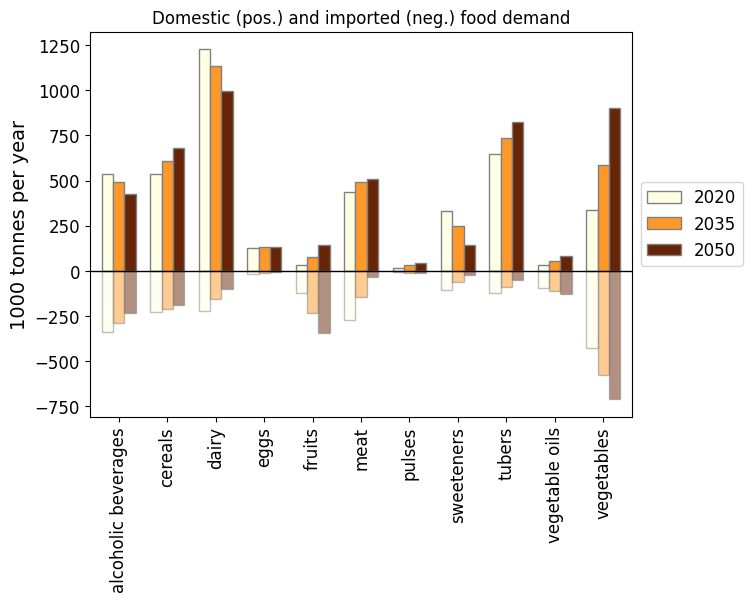

In [21]:
style = {
    'kind' : 'bar',
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.7
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = (
        session.get_attr(
            module='D',
            attr='food_demand_to_processing',
            groupby=['origin','food_group']
        ).loc[scn]
        .stack()
    )/1000000
    plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']
    
    fig, ax = plt.subplots(figsize=(7,5))
    plot_data['domestic'].unstack('year').plot(**style, ax=ax)
    (
        plot_data['imported'].unstack('year')
        .rename({x:'_' for x in plot_data.index.get_level_values('year').unique()}, axis=1)
    ).plot(**style, ax=ax, alpha=0.5)
    
    plt.hlines(0,-1,11, color='black', linewidth=1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_ylabel('1000 tonnes per year', size=14)
    ax.set_title('Domestic (pos.) and imported (neg.) food demand', size=12)
    ax.set_xlabel('')
    ax.legend(loc='center left', ncol=1, bbox_to_anchor=(1, 0.5), fontsize=12)
    
    # plt.tight_layout()
    plt.show()

FAI
---


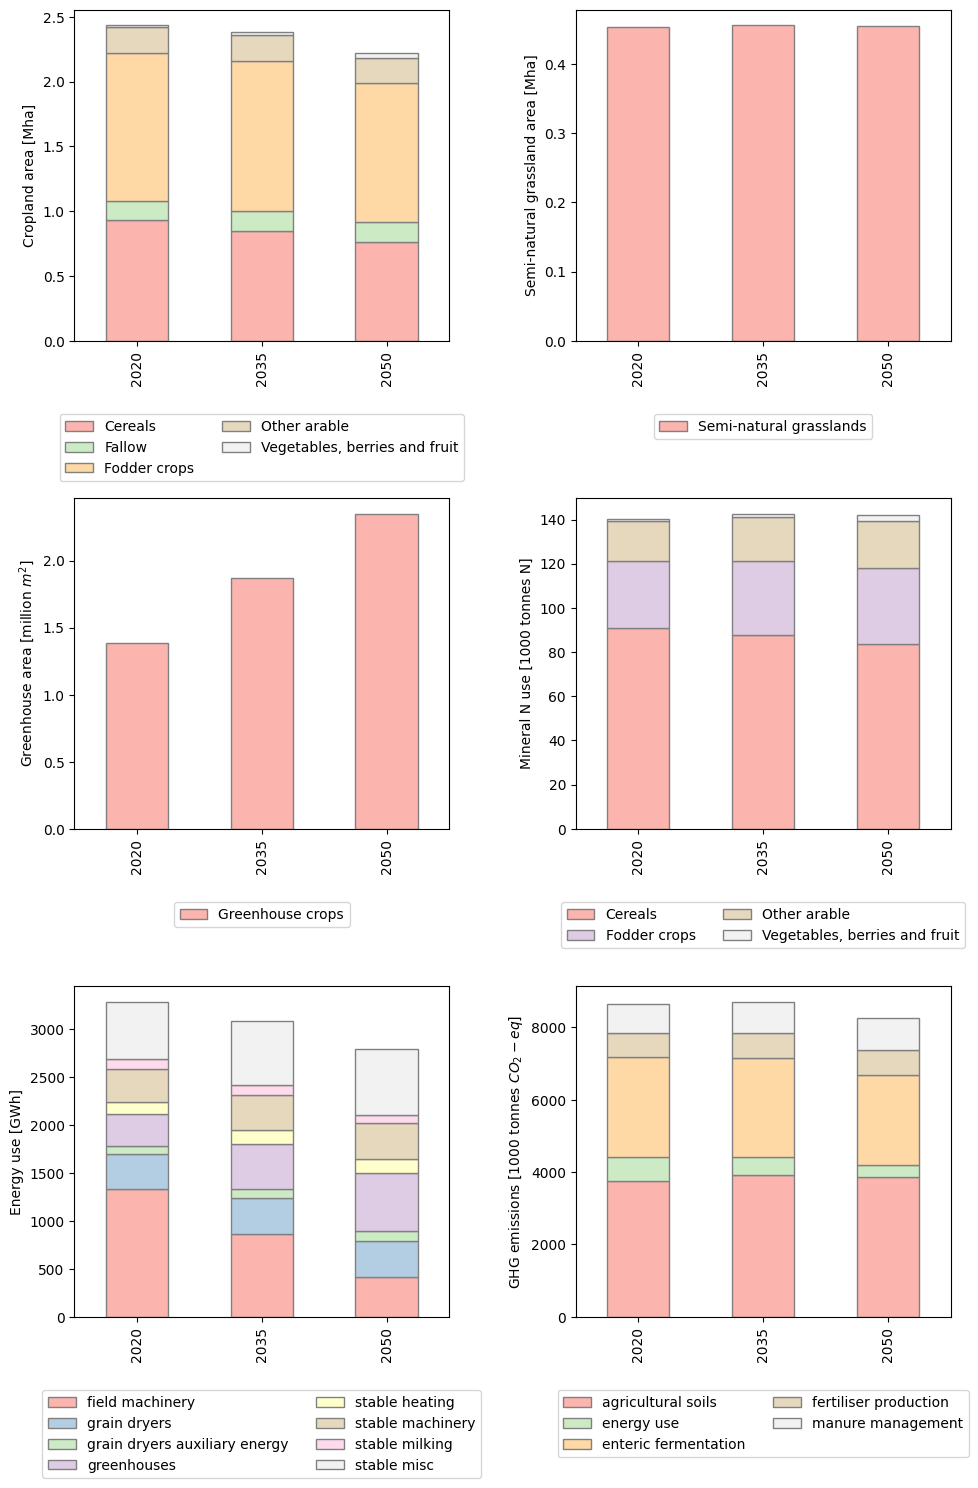

In [11]:
style = {
    'kind' : 'bar',
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.5
}

# Get data on GHG emissions
GHG_data = cm.get_GHG(session)

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))

    fig, axs = plt.subplots(3,2, figsize=(10,15))

    # Land use --->
    plot_data = session.get_attr('C','area',{'crop':'crop_group2'}).loc[scn]/1000000
    
    # Cropland
    ax = axs[0,0]
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Cropland area [Mha]')
    
    # Semi-natural grassland
    ax = axs[0,1]
    plot_data.xs('Semi-natural grasslands', axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Semi-natural grassland area [Mha]')
    
    # Greenhouse
    ax = axs[1,0]
    plot_data.xs('Greenhouse crops', axis=1).plot(**style, ax=ax)
    ax.set_ylabel(r'Greenhouse area [million $m^2$]')

    # Mineral N use --->
    ax = axs[1,1]
    (session.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000).loc[scn].plot(**style, ax=ax)
    ax.set_ylabel('Mineral N use [1000 tonnes N]')

    # Energy use --->
    ax = axs[2,0]
    pd.concat([
        session.get_attr('C','energy_use','activity').loc[scn]/1000000,
        session.get_attr('A','energy_use','activity').loc[scn]/1000000
    ], axis=1).plot(**style, ax=ax)
    ax.set_ylabel('Energy use [GWh]')
    
    # GHG emissions
    ax = axs[2,1]
    plot_data = (GHG_data/1000000).loc[scn]
    (
        plot_data
        .T.groupby('process').sum().T
    ).plot(**style, ax=ax)
    ax.set_ylabel(r'GHG emissions [1000 tonnes $CO_{2}-eq$]')
    
    for ax in axs.flatten():
        ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=10)
        ax.set_xlabel('')

    fig.tight_layout()
    plt.show()

FAI
---


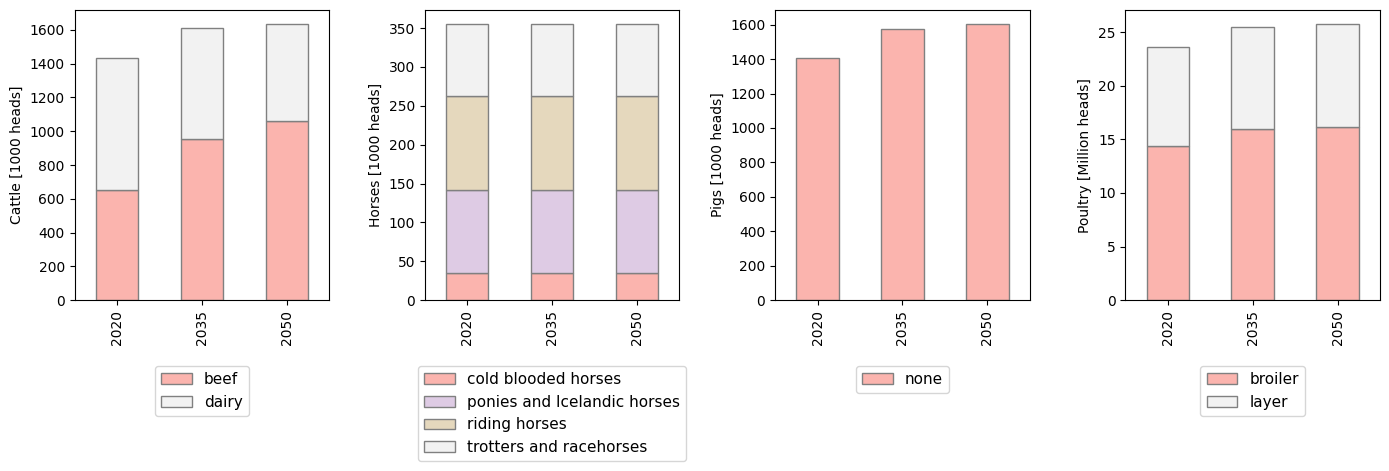

In [12]:
style = {
    'kind' : 'bar',
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'legend' : False,
    'width' : 0.5
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    # Number of animal heads
    plot_data = session.get_attr('A','heads',['species','breed']).loc[scn]

    fig, axs = plt.subplots(1,4, figsize=(14,5))

    for ax,sp in zip(axs,plot_data.columns.get_level_values('species').unique()):

        (
            (plot_data / (1000000 if sp=='poultry' else 1000))
            .xs(sp, level='species', axis=1)
            .plot(**style, ax = ax)
        )

        ax.set_ylabel(sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]'))
        ax.set_xlabel('')
        ax.legend(loc='lower left', bbox_to_anchor=(0, 0))

    for ax in axs.flatten():
        ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.5, -0.2), fontsize=11)
        ax.set_xlabel('')
    
    plt.tight_layout()
    plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:54: SyntaxWarning: invalid escape sequence '\D'
<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:95: SyntaxWarning: invalid escape sequence '\D'
<>:108: SyntaxWarning: invalid escape sequence '\D'
<>:125: SyntaxWarning: invalid escape sequence '\D'
<>:142: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:54: SyntaxWarning: invalid escape sequence '\D'
<>:71: SyntaxWarning: invalid escape sequence '\D'
<>:95: SyntaxWarning: invalid escape sequence '\D'
<>:108: SyntaxWarning: invalid escape sequence '\D'
<>:125: SyntaxWarning: invalid escape sequence '\D'
<>:142: SyntaxWarning: invalid escape sequence '\D'
C:\Users\ÄGARE\AppData\Local\Temp\ipykernel_1008\1608385197.py:24: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
C:\Users\ÄGARE\

FAI
---


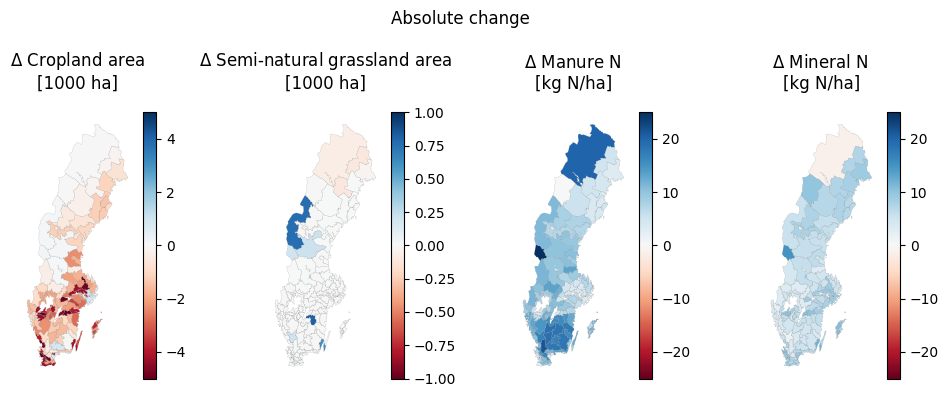

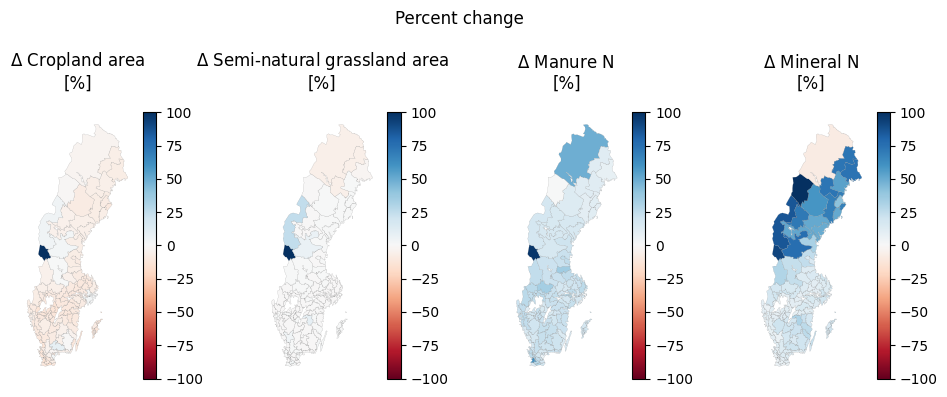

In [13]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    y0 = session.scenarios()[scn][0]
    yend = session.scenarios()[scn][-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-5,
        vmax=5,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-1,
        vmax=1,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle('Absolute change')
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[%]')
    ax.set_axis_off()
   
    
    plt.suptitle('Percent change')
    plt.tight_layout()
    plt.show()

FAI
---


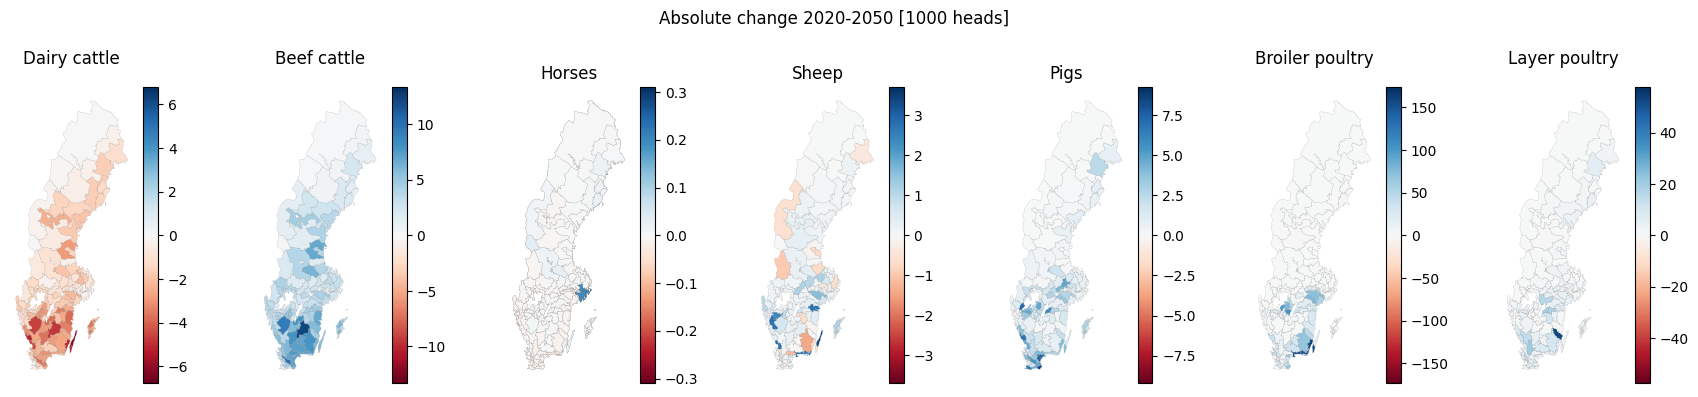

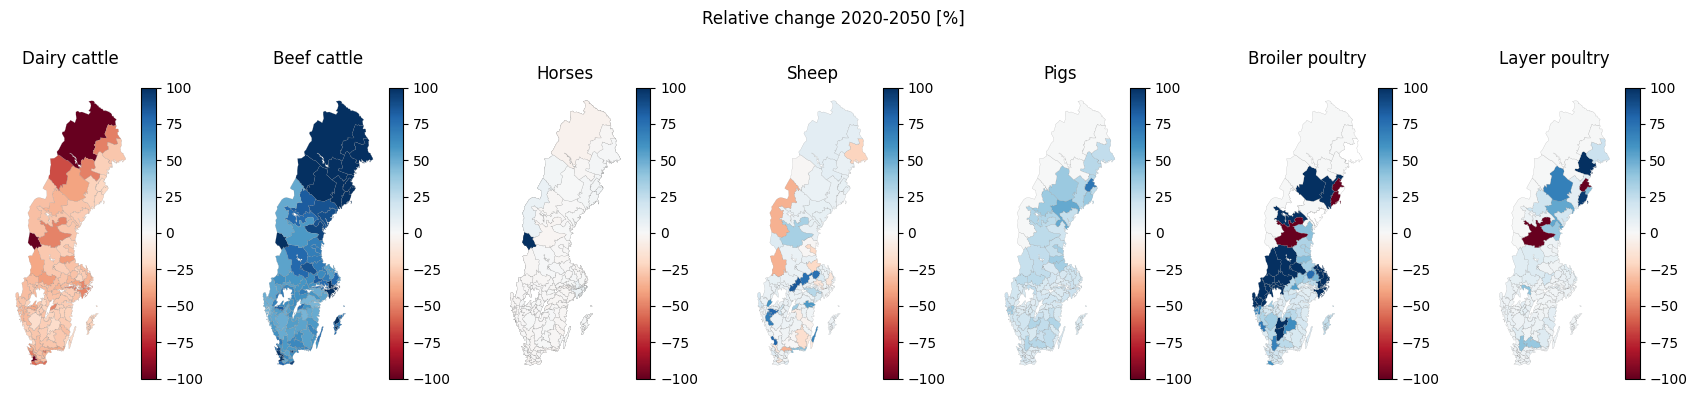

In [14]:
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Sheep':('sheep',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = session.get_attr('A','heads',['species','breed','region']).loc[scn]/1000
    plot_data_abs = (plot_data.loc['2050'] - plot_data.loc['2020']).sort_index()
    plot_data_prc = ((plot_data.loc['2050'] - plot_data.loc['2020']) / plot_data.loc['2020'] * 100).sort_index().fillna(0)
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle('Absolute change 2020-2050 [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle('Relative change 2020-2050 [%]')
    plt.tight_layout()
    plt.show()